In [1]:
# Import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully!")

Mounted at /content/drive
Google Drive connected successfully!


In [3]:
# Main project folder
PROJECT_FOLDER = "/content/drive/MyDrive/Cybersecurity_Incident_Analytics6"

# Create the 8 stage folders
stage_folders = [
    "01_Data_Loading_and_Reading",
    "02_Data_Acquisition_and_Filtering",
    "03_Data_Extraction",
    "04_Data_Validation_and_Cleaning",
    "05_Data_Aggregation_and_Representation",
    "06_Data_Analysis",
    "07_Data_Visualization",
    "08_Results_and_Interpretation"
]

# Create folders
for folder in stage_folders:
    folder_path = os.path.join(PROJECT_FOLDER, folder)
    os.makedirs(folder_path, exist_ok=True)

print("Project folder structure created successfully!\n")

print("Cybersecurity_Incident_Analytics/")
for folder in stage_folders:
    print("├──", folder + "/")

Project folder structure created successfully!

Cybersecurity_Incident_Analytics/
├── 01_Data_Loading_and_Reading/
├── 02_Data_Acquisition_and_Filtering/
├── 03_Data_Extraction/
├── 04_Data_Validation_and_Cleaning/
├── 05_Data_Aggregation_and_Representation/
├── 06_Data_Analysis/
├── 07_Data_Visualization/
├── 08_Results_and_Interpretation/


In [7]:
#Stage 1: Data Loading & Reading

# Path of the dataset
DATASET_PATH = os.path.join(
    PROJECT_FOLDER,
    "01_Data_Loading_and_Reading",
    "original_dataset.csv"
)

# Load the dataset
df = pd.read_csv(DATASET_PATH)

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 records:")
display(df.head())

Dataset loaded successfully!
Number of rows: 3000
Number of columns: 10

First 5 records:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [8]:
#STAGE 2 — Data Acquisition & Filtering
# Create a copy of the original dataset

df_acquired = df.copy()

print("Original records:", len(df_acquired))

# Remove completely empty rows
df_acquired = df_acquired.dropna(how="all")

print("Records after removing empty rows:", len(df_acquired))

#Apply Filtering

# Filter valid records

df_acquired = df_acquired[
    (df_acquired["Year"].between(2015, 2024)) &
    (df_acquired["Financial Loss (in Million $)"] >= 0) &
    (df_acquired["Number of Affected Users"] >= 0) &
    (df_acquired["Incident Resolution Time (in Hours)"] >= 0)
]

print("Records after filtering:", len(df_acquired))

display(df_acquired.head())

Original records: 3000
Records after removing empty rows: 3000
Records after filtering: 3000


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [9]:
stage2_folder = os.path.join(
    PROJECT_FOLDER,
    "02_Data_Acquisition_and_Filtering"
)

filtered_file = os.path.join(
    stage2_folder,
    "02_filtered_dataset.csv"
)

df_acquired.to_csv(
    filtered_file,
    index=False
)

print("Filtered dataset saved successfully!")
print(filtered_file)

Filtered dataset saved successfully!
/content/drive/MyDrive/Cybersecurity_Incident_Analytics6/02_Data_Acquisition_and_Filtering/02_filtered_dataset.csv


In [10]:
#STAGE 3 — Data Extraction
required_columns = [
    "Country",
    "Year",
    "Attack Type",
    "Target Industry",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Attack Source",
    "Security Vulnerability Type",
    "Defense Mechanism Used",
    "Incident Resolution Time (in Hours)"
]

df_extracted = df_acquired[required_columns].copy()

print("Required columns extracted successfully!")

print("\nExtracted columns:")
print(df_extracted.columns.tolist())

display(df_extracted.head())

Required columns extracted successfully!

Extracted columns:
['Country', 'Year', 'Attack Type', 'Target Industry', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used', 'Incident Resolution Time (in Hours)']


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [11]:
stage3_folder = os.path.join(
    PROJECT_FOLDER,
    "03_Data_Extraction"
)

extracted_file = os.path.join(
    stage3_folder,
    "03_extracted_dataset.csv"
)

df_extracted.to_csv(
    extracted_file,
    index=False
)

print("Extracted dataset saved successfully!")

Extracted dataset saved successfully!


In [12]:
#STAGE 4 — Data Validation & Cleaning
#Check Missing Values & Duplicates
df_clean = df_extracted.copy()

print("===== MISSING VALUES =====")
print(df_clean.isnull().sum())

print("\n===== DUPLICATE ROWS =====")
print(df_clean.duplicated().sum())

#Clean Data
# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove extra spaces from text values
text_columns = df_clean.select_dtypes(include="object").columns

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Convert numeric columns
numeric_columns = [
    "Year",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

# Remove missing values
df_clean = df_clean.dropna()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

print("Data cleaning completed!")
print("Rows after cleaning:", len(df_clean))

===== MISSING VALUES =====
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

===== DUPLICATE ROWS =====
0
Data cleaning completed!
Rows after cleaning: 3000


In [13]:
#Validate Again
print("===== AFTER CLEANING =====")

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

===== AFTER CLEANING =====

Missing values:
Country                                0
Year                                   0
Attack Type                            0
Target Industry                        0
Financial Loss (in Million $)          0
Number of Affected Users               0
Attack Source                          0
Security Vulnerability Type            0
Defense Mechanism Used                 0
Incident Resolution Time (in Hours)    0
dtype: int64

Duplicate rows:
0

Data types:
Country                                 object
Year                                     int64
Attack Type                             object
Target Industry                         object
Financial Loss (in Million $)          float64
Number of Affected Users                 int64
Attack Source                           object
Security Vulnerability Type             object
Defense Mechanism Used                  object
Incident Resolution Time (in Hours)      int64
dtype: object


In [14]:
stage4_folder = os.path.join(
    PROJECT_FOLDER,
    "04_Data_Validation_and_Cleaning"
)

cleaned_file = os.path.join(
    stage4_folder,
    "04_cleaned_dataset.csv"
)

df_clean.to_csv(
    cleaned_file,
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [15]:
#STAGE 5 — Data Aggregation & Representation
#Attack Type Summary
attack_type_summary = (
    df_clean
    .groupby("Attack Type")
    .size()
    .reset_index(name="Incident Count")
)

print("Attack Type Summary:")
display(attack_type_summary)

Attack Type Summary:


,Attack Type,Incident Count
0,DDoS,531
1,Malware,485
2,Man-in-the-Middle,459
3,Phishing,529
4,Ransomware,493
5,SQL Injection,503


In [16]:
#Yearly Summary
yearly_summary = (
    df_clean
    .groupby("Year")
    .size()
    .reset_index(name="Incident Count")
)

print("Yearly Incident Summary:")
display(yearly_summary)

Yearly Incident Summary:


,Year,Incident Count
0,2015,277
1,2016,285
2,2017,319
3,2018,310
4,2019,263
5,2020,315
6,2021,299
7,2022,318
8,2023,315
9,2024,299


In [17]:
#Industry Summary
industry_summary = (
    df_clean
    .groupby("Target Industry")
    .size()
    .reset_index(name="Incident Count")
)

print("Target Industry Summary:")
display(industry_summary)

Target Industry Summary:


,Target Industry,Incident Count
0,Banking,445
1,Education,419
2,Government,403
3,Healthcare,429
4,IT,478
5,Retail,423
6,Telecommunications,403


In [18]:
#Attack Source Summary
attack_source_summary = (
    df_clean
    .groupby("Attack Source")
    .size()
    .reset_index(name="Incident Count")
)

print("Attack Source Summary:")
display(attack_source_summary)

Attack Source Summary:


,Attack Source,Incident Count
0,Hacker Group,686
1,Insider,752
2,Nation-state,794
3,Unknown,768


In [19]:
#Attack Type × Industry
attack_industry_table = pd.crosstab(
    df_clean["Attack Type"],
    df_clean["Target Industry"]
)

print("Attack Type vs Target Industry:")
display(attack_industry_table)

Attack Type vs Target Industry:


Target Industry,Banking,Education,Government,Healthcare,IT,Retail,Telecommunications
Attack Type,,,,,,,
DDoS,71,73,71,78,91,62,85
Malware,61,70,64,81,67,68,74
Man-in-the-Middle,77,65,53,58,80,70,56
Phishing,96,73,68,63,89,89,51
Ransomware,69,71,72,77,74,71,59
SQL Injection,71,67,75,72,77,63,78


In [21]:
stage5_folder = os.path.join(
    PROJECT_FOLDER,
    "05_Data_Aggregation_and_Representation"
)

attack_type_summary.to_csv(
    os.path.join(stage5_folder, "attack_type_summary.csv"),
    index=False
)

yearly_summary.to_csv(
    os.path.join(stage5_folder, "yearly_summary.csv"),
    index=False
)

industry_summary.to_csv(
    os.path.join(stage5_folder, "industry_summary.csv"),
    index=False
)

attack_source_summary.to_csv(
    os.path.join(stage5_folder, "attack_source_summary.csv"),
    index=False
)

attack_industry_table.to_csv(
    os.path.join(stage5_folder, "attack_industry_table.csv")
)

print("Aggregation results saved successfully!")

Aggregation results saved successfully!


In [22]:
#TAGE 6 — Data Analysis
#Statistical Analysis
print("===== STATISTICAL ANALYSIS =====")

display(
    df_clean[
        [
            "Year",
            "Financial Loss (in Million $)",
            "Number of Affected Users",
            "Incident Resolution Time (in Hours)"
        ]
    ].describe()
)

===== STATISTICAL ANALYSIS =====


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2019.570333,50.492970,504684.136333,36.476000
std,2.857932,28.791415,289944.084972,20.570768
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.757500,255805.250000,19.000000
50%,2020.000000,50.795000,504513.000000,37.000000
75%,2022.000000,75.630000,758088.500000,55.000000
max,2024.000000,99.990000,999635.000000,72.000000


In [23]:
#Correlation Analysis
numeric_columns = [
    "Year",
    "Financial Loss (in Million $)",
    "Number of Affected Users",
    "Incident Resolution Time (in Hours)"
]

correlation_matrix = df_clean[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Year,1.000000,0.010581,0.002317,-0.004982
Financial Loss (in Million $),0.010581,1.000000,0.001787,-0.012671
Number of Affected Users,0.002317,0.001787,1.000000,0.005893
Incident Resolution Time (in Hours),-0.004982,-0.012671,0.005893,1.000000


In [24]:
#Top Financial Loss Incidents
top_loss_incidents = (
    df_clean
    .sort_values(
        by="Financial Loss (in Million $)",
        ascending=False
    )
    .head(10)
)

print("Top 10 Financial Loss Incidents:")
display(top_loss_incidents)

Top 10 Financial Loss Incidents:


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
1806,Australia,2017,SQL Injection,IT,99.99,672966,Hacker Group,Zero-day,Firewall,13
2030,China,2024,DDoS,Banking,99.99,755185,Unknown,Weak Passwords,Encryption,20
2133,Germany,2016,Phishing,Telecommunications,99.98,761576,Insider,Unpatched Software,Antivirus,9
419,Germany,2019,Phishing,Healthcare,99.97,950451,Hacker Group,Weak Passwords,AI-based Detection,29
1363,Brazil,2020,Ransomware,Banking,99.90,429566,Nation-state,Zero-day,AI-based Detection,54
2004,USA,2016,Ransomware,Telecommunications,99.88,999508,Unknown,Unpatched Software,VPN,23
2092,Germany,2015,Ransomware,Telecommunications,99.83,419344,Hacker Group,Zero-day,Firewall,59
2228,Japan,2020,DDoS,Education,99.83,10859,Nation-state,Social Engineering,AI-based Detection,66
1678,USA,2020,DDoS,Banking,99.81,948174,Unknown,Social Engineering,AI-based Detection,4
2428,USA,2021,DDoS,Telecommunications,99.81,460842,Unknown,Weak Passwords,AI-based Detection,59


In [25]:
#Save Analysis
stage6_folder = os.path.join(
    PROJECT_FOLDER,
    "06_Data_Analysis"
)

correlation_matrix.to_csv(
    os.path.join(stage6_folder, "correlation_matrix.csv")
)

top_loss_incidents.to_csv(
    os.path.join(stage6_folder, "top_loss_incidents.csv"),
    index=False
)

print("Analysis results saved successfully!")

Analysis results saved successfully!


In [26]:
#STAGE 7 — Data Visualization
stage7_folder = os.path.join(
    PROJECT_FOLDER,
    "07_Data_Visualization"
)

os.makedirs(stage7_folder, exist_ok=True)

print("Visualization folder ready!")

Visualization folder ready!


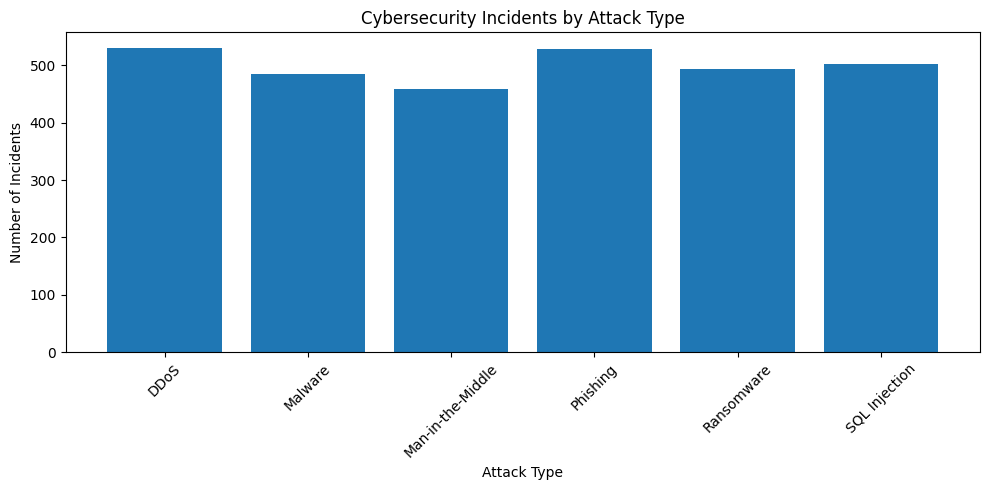

In [27]:
#Attack Type Chart
plt.figure(figsize=(10, 5))

plt.bar(
    attack_type_summary["Attack Type"],
    attack_type_summary["Incident Count"]
)

plt.title("Cybersecurity Incidents by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "01_attack_type_distribution.png"
    )
)

plt.show()

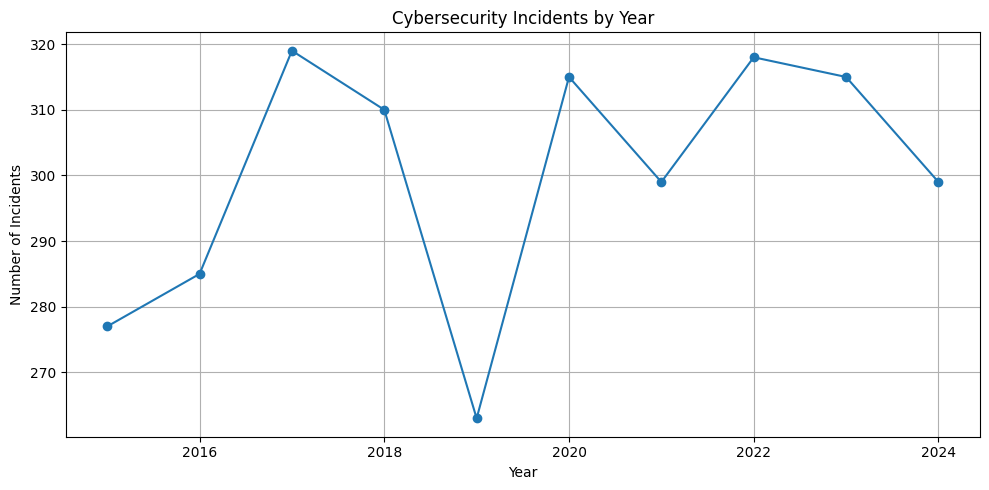

In [28]:
#Yearly Trend
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_summary["Year"],
    yearly_summary["Incident Count"],
    marker="o"
)

plt.title("Cybersecurity Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "02_yearly_incidents.png"
    )
)

plt.show()

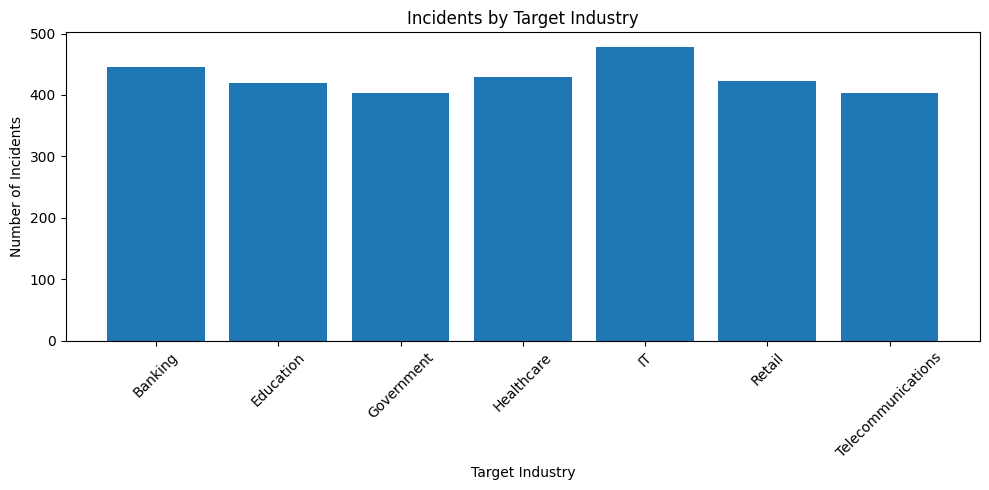

In [29]:
#Industry Chart
plt.figure(figsize=(10, 5))

plt.bar(
    industry_summary["Target Industry"],
    industry_summary["Incident Count"]
)

plt.title("Incidents by Target Industry")
plt.xlabel("Target Industry")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "03_industry_incidents.png"
    )
)

plt.show()

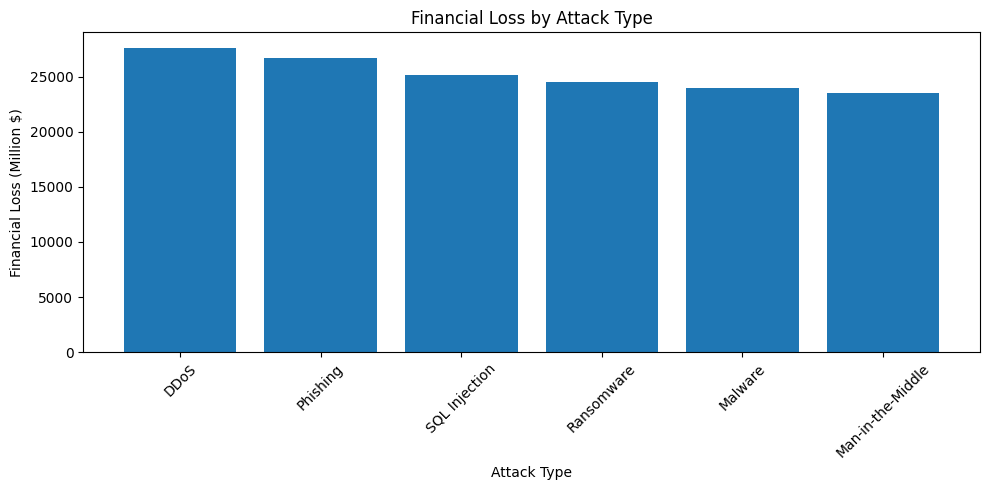

In [30]:
#Financial Loss by Attack
loss_by_attack = (
    df_clean
    .groupby("Attack Type")[
        "Financial Loss (in Million $)"
    ]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    loss_by_attack.index,
    loss_by_attack.values
)

plt.title("Financial Loss by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Financial Loss (Million $)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "04_financial_loss_by_attack.png"
    )
)

plt.show()

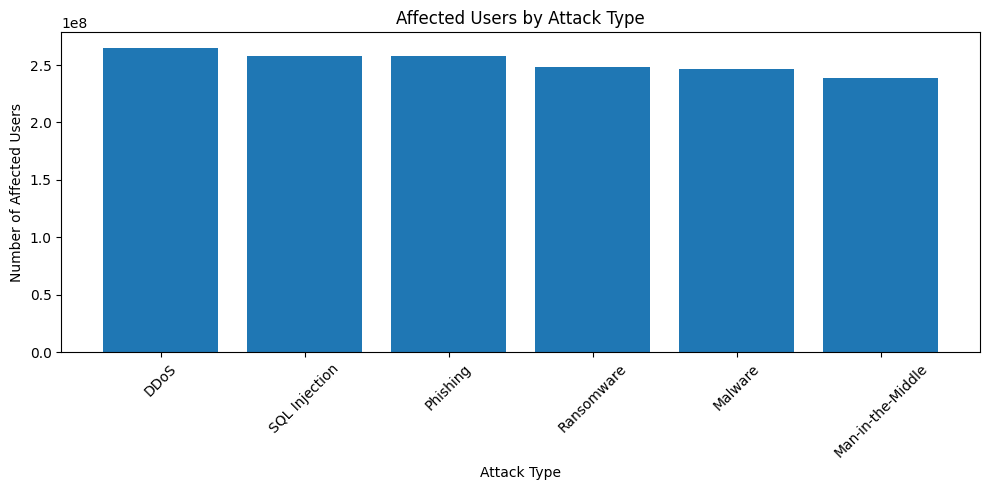

In [31]:
#Affected Users
users_by_attack = (
    df_clean
    .groupby("Attack Type")[
        "Number of Affected Users"
    ]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    users_by_attack.index,
    users_by_attack.values
)

plt.title("Affected Users by Attack Type")
plt.xlabel("Attack Type")
plt.ylabel("Number of Affected Users")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "05_affected_users_by_attack.png"
    )
)

plt.show()

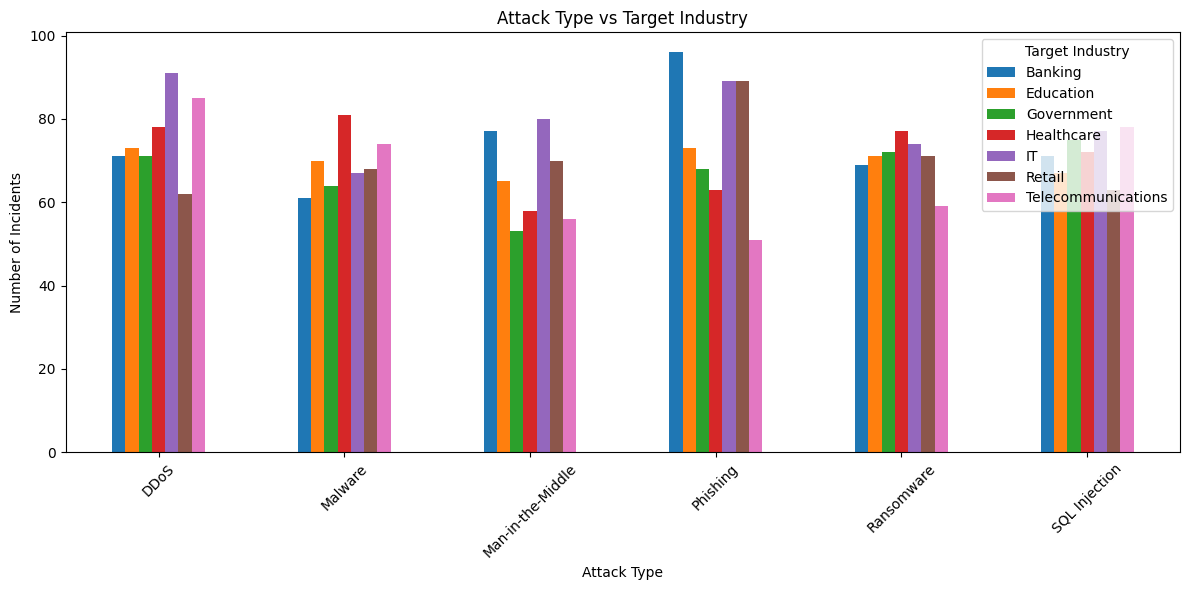

In [32]:
#Attack vs Industry
attack_industry_table.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Attack Type vs Target Industry")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "06_attack_vs_industry.png"
    )
)

plt.show()

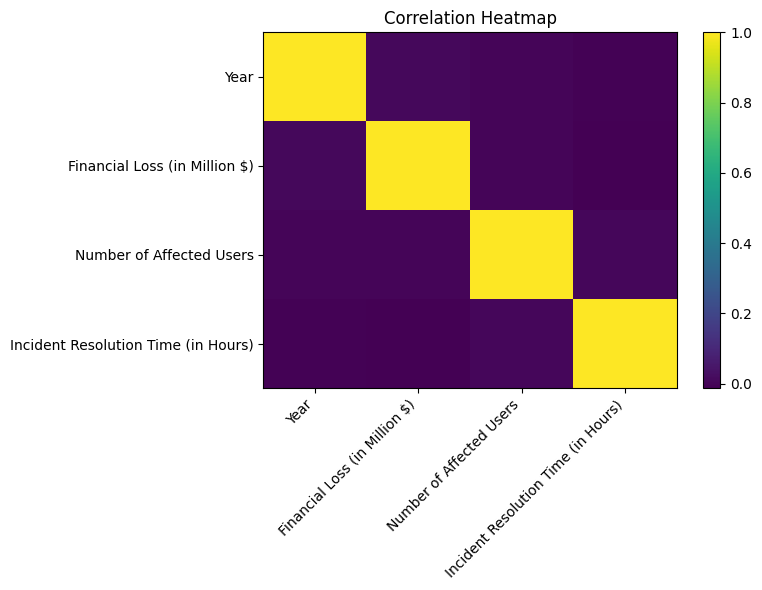

In [33]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(
        stage7_folder,
        "07_correlation_heatmap.png"
    )
)

plt.show()

In [34]:
#STAGE 8 — Results & Interpretation
#Generate Findings
stage8_folder = os.path.join(
    PROJECT_FOLDER,
    "08_Results_and_Interpretation"
)

# Most common attack
most_common_attack = attack_type_summary.loc[
    attack_type_summary["Incident Count"].idxmax()
]

# Most targeted industry
most_targeted_industry = industry_summary.loc[
    industry_summary["Incident Count"].idxmax()
]

# Year with most incidents
highest_incident_year = yearly_summary.loc[
    yearly_summary["Incident Count"].idxmax()
]

print("===== KEY FINDINGS =====")

print(
    "1. Most common attack type:",
    most_common_attack["Attack Type"]
)

print(
    "2. Most targeted industry:",
    most_targeted_industry["Target Industry"]
)

print(
    "3. Year with most incidents:",
    int(highest_incident_year["Year"])
)

===== KEY FINDINGS =====
1. Most common attack type: DDoS
2. Most targeted industry: IT
3. Year with most incidents: 2017


In [35]:
#Save Results
findings = {
    "Finding": [
        "Most Common Attack Type",
        "Most Targeted Industry",
        "Year With Most Incidents"
    ],
    "Result": [
        most_common_attack["Attack Type"],
        most_targeted_industry["Target Industry"],
        int(highest_incident_year["Year"])
    ]
}

findings_df = pd.DataFrame(findings)

findings_df.to_csv(
    os.path.join(
        stage8_folder,
        "key_findings.csv"
    ),
    index=False
)

print("Key findings saved successfully!")

Key findings saved successfully!


In [37]:
#Final Conclusion
conclusion = """
CYBERSECURITY INCIDENT ANALYTICS - CONCLUSION

The cybersecurity incident dataset was successfully loaded,
filtered, extracted, validated, cleaned, aggregated and analyzed.

The analysis examined attack types, target industries,
attack sources, financial losses, affected users and
incident resolution time.

The results were represented using tables and visualizations
to make cybersecurity incident patterns easier to understand.

The project completed all eight required stages of the
data analytics workflow.
"""

with open(
    os.path.join(
        stage8_folder,
        "conclusion.txt"
    ),
    "w"
) as file:
    file.write(conclusion)

print(conclusion)


CYBERSECURITY INCIDENT ANALYTICS - CONCLUSION

The cybersecurity incident dataset was successfully loaded,
filtered, extracted, validated, cleaned, aggregated and analyzed.

The analysis examined attack types, target industries,
attack sources, financial losses, affected users and
incident resolution time.

The results were represented using tables and visualizations
to make cybersecurity incident patterns easier to understand.

The project completed all eight required stages of the
data analytics workflow.



In [38]:
print("=" * 70)
print("CYBERSECURITY INCIDENT ANALYTICS")
print("FINAL PROJECT CHECK")
print("=" * 70)

for number, folder in enumerate(stage_folders, 1):

    folder_path = os.path.join(
        PROJECT_FOLDER,
        folder
    )

    files = os.listdir(folder_path)

    print(f"\n{number}. {folder}")

    if files:
        for file in files:
            print("   └──", file)
    else:
        print("   └── Empty")

print("\n" + "=" * 70)
print("ALL 8 STAGES COMPLETED")
print("=" * 70)

CYBERSECURITY INCIDENT ANALYTICS
FINAL PROJECT CHECK

1. 01_Data_Loading_and_Reading
   └── original_dataset.csv

2. 02_Data_Acquisition_and_Filtering
   └── 02_filtered_dataset.csv

3. 03_Data_Extraction
   └── 03_extracted_dataset.csv

4. 04_Data_Validation_and_Cleaning
   └── 04_cleaned_dataset.csv

5. 05_Data_Aggregation_and_Representation
   └── attack_type_summary.csv
   └── yearly_summary.csv
   └── industry_summary.csv
   └── attack_source_summary.csv
   └── attack_industry_table.csv

6. 06_Data_Analysis
   └── correlation_matrix.csv
   └── top_loss_incidents.csv

7. 07_Data_Visualization
   └── 01_attack_type_distribution.png
   └── 02_yearly_incidents.png
   └── 03_industry_incidents.png
   └── 04_financial_loss_by_attack.png
   └── 05_affected_users_by_attack.png
   └── 06_attack_vs_industry.png
   └── 07_correlation_heatmap.png

8. 08_Results_and_Interpretation
   └── key_findings.csv
   └── conclusion.txt

ALL 8 STAGES COMPLETED
